In [2]:
import torch
import pandas as pd
import numpy as np
import time
import re
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import matplotlib.pyplot as plt
from collections import Counter

# Конфигурация
MODELS = {
    "baseline": "./ruGPT3medium_based_on_gpt2",
    "advanced": "./ruGPT3_finetuned_advanced",
    "manual": "./ruGPT3_manual_finetuned"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEMPERATURE = 0.3
MAX_NEW_TOKENS = 150
TOP_K = 50
TOP_P = 0.9
REPETITION_PENALTY = 1.1

print(f"Устройство: {DEVICE}")

Устройство: cuda


In [3]:
def load_model(path):
    tokenizer = GPT2Tokenizer.from_pretrained(path)
    tokenizer.pad_token = tokenizer.eos_token
    model = GPT2LMHeadModel.from_pretrained(path).to(DEVICE)
    model.eval()
    return model, tokenizer

models = {}
for name, path in MODELS.items():
    try:
        models[name] = load_model(path)
        print(f"✅ {name} загружена")
    except Exception as e:
        print(f"❌ Ошибка загрузки {name}: {e}")
        models[name] = (None, None)

Loading weights: 100%|██████████| 293/293 [00:00<00:00, 13667.39it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: ./ruGPT3medium_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ baseline загружена


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 393.56it/s]


✅ advanced загружена


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 423.19it/s]


✅ manual загружена


In [4]:
def build_prompt(plan):
    parts = []
    if plan.get('title'):
        parts.append(f"Название мероприятия: {plan['title']}")
    if plan.get('event_date'):
        parts.append(f"Дата: {plan['event_date']}")
    if plan.get('event_time'):
        parts.append(f"Время: {plan['event_time'][:5]}")
    if plan.get('event_end_time'):
        parts.append(f"Окончание: {plan['event_end_time'][:5]}")
    if plan.get('location'):
        parts.append(f"Место проведения: {plan['location']}")
    if plan.get('format_type'):
        parts.append(f"Формат: {plan['format_type']}")
    if plan.get('category'):
        parts.append(f"Категория: {plan['category']}")
    if plan.get('participants_count'):
        parts.append(f"Количество участников: {plan['participants_count']}")
    if plan.get('description'):
        parts.append(f"Описание: {plan['description']}")
    if plan.get('goal'):
        parts.append(f"Цель: {plan['goal']}")
    if plan.get('speaker'):
        parts.append(f"Спикер(ы): {plan['speaker']}")
    if plan.get('audience'):
        parts.append(f"Аудитория: {plan['audience']}")
    if plan.get('organizer'):
        parts.append(f"Организатор: {plan['organizer']}")
    return ". ".join(parts) + ". Новость:"

def extract_numbers(text):
    return set(re.findall(r'\b\d+\b', text))

def calculate_lexical_diversity(text):
    words = re.findall(r'\b[а-яё]+\b', text.lower())
    if not words:
        return 0
    return len(set(words)) / len(words)

def calculate_metrics(prompt, generated_text, plan):
    """Возвращает словарь с метриками для одного примера."""
    # 1. Длина текста
    text_len_chars = len(generated_text)
    text_len_tokens = len(generated_text.split())  # приближённо
    
    # 2. Лексическое разнообразие
    lexical_diversity = calculate_lexical_diversity(generated_text)
    
    # 3. Совпадение чисел (извлечённых из плана)
    expected_numbers = extract_numbers(prompt)
    actual_numbers = extract_numbers(generated_text)
    if expected_numbers:
        number_accuracy = len(actual_numbers.intersection(expected_numbers)) / len(expected_numbers)
    else:
        number_accuracy = 1.0  # нет чисел – нет ошибок
    
    # 4. Проверка на повторяющиеся слова (коэффициент повторений)
    words = re.findall(r'\b[а-яё]+\b', generated_text.lower())
    word_freq = Counter(words)
    repetition_rate = sum(1 for w, c in word_freq.items() if c > 2) / max(len(word_freq), 1)
    
    return {
        "length_chars": text_len_chars,
        "length_tokens": text_len_tokens,
        "lexical_diversity": lexical_diversity,
        "number_accuracy": number_accuracy,
        "repetition_rate": repetition_rate
    }

def generate_with_metrics(model, tokenizer, prompt):
    if model is None:
        return "Ошибка: модель не загружена", 0, {}
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=TEMPERATURE,
            top_k=TOP_K,
            top_p=TOP_P,
            repetition_penalty=REPETITION_PENALTY,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    elapsed = time.time() - start
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Новость:" in generated:
        generated = generated.split("Новость:")[-1].strip()
    
    # Вычисляем метрики
    metrics = calculate_metrics(prompt, generated, {})
    return generated, elapsed, metrics

In [6]:
test_plans = [
    {  # План 1: мастер-класс
        "title": "Практикум по разработке Telegram-ботов на Python",
        "event_date": "20.07.2026",
        "event_time": "14:00",
        "event_end_time": "18:00",
        "location": "Санкт-Петербург, IT-парк «Астория»",
        "format_type": "Очный",
        "category": "Мастер-класс",
        "participants_count": "30",
        "description": "Участники напишут ботов с использованием библиотеки aiogram.",
        "goal": "Обучение практическим навыкам",
        "speaker": "Дмитрий Лебедев (VK)",
        "audience": "Начинающие Python-разработчики",
        "organizer": "Академия Яндекса"
    },
    {  # План 2: хакатон
        "title": "Хакатон по искусственному интеллекту",
        "event_date": "15.06.2025",
        "event_time": "10:00",
        "event_end_time": "18:00",
        "location": "Москва, Технопарк Сколково",
        "format_type": "Очный",
        "category": "Хакатон",
        "participants_count": "120",
        "description": "Создание прототипов нейросетей для предсказания спроса.",
        "goal": "Создание работающих моделей",
        "speaker": "Алексей Федотов (Яндекс)",
        "audience": "Дата-сайентисты",
        "organizer": "Фонд Сколково"
    },
    {  # План 3: онлайн-вебинар (пропущены некоторые поля)
        "title": "Вебинар по финансовой грамотности",
        "event_date": "05.12.2025",
        "event_time": "16:00",
        "location": "Онлайн",
        "format_type": "Онлайн",
        "category": "Вебинар",
        "participants_count": "200",
        "description": "Бюджетирование и инвестиции.",
        "goal": "Повышение грамотности",
        "speaker": "Елена Миронова (Банк России)",
        "audience": "Широкая публика"
    },
    {  # План 4: фестиваль
        "title": "Фестиваль уличной еды",
        "event_date": "22.05.2025",
        "event_time": "12:00",
        "event_end_time": "22:00",
        "location": "Казань, набережная",
        "format_type": "Очный",
        "category": "Фестиваль",
        "participants_count": "3000",
        "description": "Дегустация блюд, конкурсы.",
        "goal": "Популяризация локальной кухни",
        "audience": "Жители и гости"
    }
]

In [7]:
print("\n" + "="*100)
print("СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСТВА")
print("="*100)

results = []
metrics_summary = {name: {"length": [], "lexical": [], "number_acc": [], "repetition": [], "time": []} for name in MODELS}

for plan_idx, plan in enumerate(test_plans):
    print(f"\n--- План {plan_idx+1}: {plan.get('title', 'Без названия')} ---\n")
    prompt = build_prompt(plan)
    print("ПРОМПТ:\n", prompt[:300] + "..." if len(prompt) > 300 else prompt, "\n")
    
    for name, (model, tokenizer) in models.items():
        if model is None:
            continue
        text, gen_time, metrics = generate_with_metrics(model, tokenizer, prompt)
        print(f"=== {name.upper()} (время: {gen_time:.2f} с) ===")
        print(text[:500] + "..." if len(text) > 500 else text)
        print(f"  Длина: {metrics['length_chars']} симв, лекс. разнообразие: {metrics['lexical_diversity']:.2f}")
        print(f"  Точность чисел: {metrics['number_accuracy']:.2f}, повторений: {metrics['repetition_rate']:.2f}")
        print("-"*60 + "\n")
        
        results.append({
            "План": plan['title'],
            "Модель": name,
            "Время (с)": round(gen_time, 2),
            "Длина (симв)": metrics['length_chars'],
            "Лекс. разнообразие": round(metrics['lexical_diversity'], 3),
            "Точность чисел": round(metrics['number_accuracy'], 3),
            "Коэф. повторений": round(metrics['repetition_rate'], 3),
            "Текст": text
        })
        # Сохраняем для усреднения
        metrics_summary[name]["length"].append(metrics['length_chars'])
        metrics_summary[name]["lexical"].append(metrics['lexical_diversity'])
        metrics_summary[name]["number_acc"].append(metrics['number_accuracy'])
        metrics_summary[name]["repetition"].append(metrics['repetition_rate'])
        metrics_summary[name]["time"].append(gen_time)

# Сохраняем детальные результаты в CSV
df_results = pd.DataFrame(results)
df_results.to_csv("models_comparison_detailed.csv", index=False, encoding="utf-8-sig")
print("\n✅ Детальные результаты сохранены в models_comparison_detailed.csv")


СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСТВА

--- План 1: Практикум по разработке Telegram-ботов на Python ---

ПРОМПТ:
 Название мероприятия: Практикум по разработке Telegram-ботов на Python. Дата: 20.07.2026. Время: 14:00. Окончание: 18:00. Место проведения: Санкт-Петербург, IT-парк «Астория». Формат: Очный. Категория: Мастер-класс. Количество участников: 30. Описание: Участники напишут ботов с использованием библио... 



[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


=== BASELINE (время: 11.95 с) ===
В рамках мастер-класса состоится презентация новой версии платформы для разработки приложений на PHP и JavaScript — Telegram.

Власти Москвы в ближайшее время планируют ввести плату за парковку автомобилей на тротуарах, сообщает РИАМО . Соответствующее распоряжение подписал мэр столицы Сергей Собянин. «На сегодняшний день плата за стоянку транспортных средств на тротуаре составляет 1 рубль 50 копеек», - говорится в документе. Ранее сообщалось , что власти Москвы намерены установить плату за стоя...
  Длина: 735 симв, лекс. разнообразие: 0.82
  Точность чисел: 0.14, повторений: 0.04
------------------------------------------------------------

=== ADVANCED (время: 6.40 с) ===
20 июля в 14:30 в Санкт-Петербурге прошёл(ла) мастер-класс «Практикум на тему «Тренинг на тему»» . участники научатся созданию нейросетей  Цель – повышение квалификации в области искусственного интеллекта.  Спикеры: Дмитрий Лебедев («Вконтакте»).  Мероприятие ориентировано на марке

In [8]:
# Вычисляем средние значения
avg_metrics = []
for name in MODELS:
    if not metrics_summary[name]["length"]:
        continue
    avg_metrics.append({
        "Модель": name,
        "Средняя длина (симв)": np.mean(metrics_summary[name]["length"]),
        "Среднее лекс. разнообразие": np.mean(metrics_summary[name]["lexical"]),
        "Средняя точность чисел": np.mean(metrics_summary[name]["number_acc"]),
        "Средний коэф. повторений": np.mean(metrics_summary[name]["repetition"]),
        "Среднее время (с)": np.mean(metrics_summary[name]["time"])
    })

df_avg = pd.DataFrame(avg_metrics)
print("\n" + "="*80)
print("УСРЕДНЁННЫЕ МЕТРИКИ ПО ВСЕМ ПЛАНАМ")
print("="*80)
print(df_avg.to_string(index=False))
df_avg.to_csv("models_average_metrics.csv", index=False, encoding="utf-8-sig")


УСРЕДНЁННЫЕ МЕТРИКИ ПО ВСЕМ ПЛАНАМ
  Модель  Средняя длина (симв)  Среднее лекс. разнообразие  Средняя точность чисел  Средний коэф. повторений  Среднее время (с)
baseline                 690.5                    0.785279                0.160714                  0.058447           7.752694
advanced                 617.5                    0.767420                0.660714                  0.062210           6.398335
  manual                 752.5                    0.806635                0.267857                  0.045242           6.334626


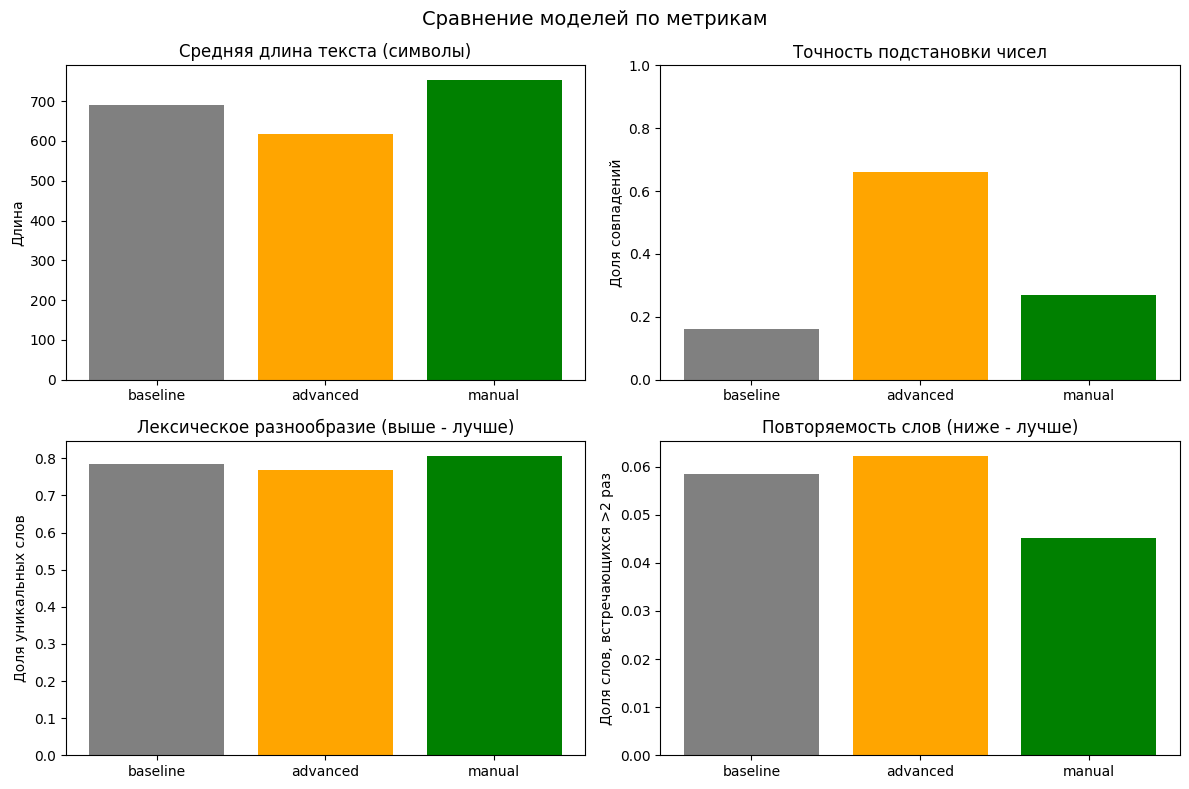

In [9]:
# Построим графики для наглядности
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Сравнение моделей по метрикам", fontsize=14)

# 1. Средняя длина
axes[0,0].bar(df_avg["Модель"], df_avg["Средняя длина (симв)"], color=['gray', 'orange', 'green'])
axes[0,0].set_title("Средняя длина текста (символы)")
axes[0,0].set_ylabel("Длина")

# 2. Точность чисел
axes[0,1].bar(df_avg["Модель"], df_avg["Средняя точность чисел"], color=['gray', 'orange', 'green'])
axes[0,1].set_title("Точность подстановки чисел")
axes[0,1].set_ylabel("Доля совпадений")
axes[0,1].set_ylim(0, 1)

# 3. Лексическое разнообразие
axes[1,0].bar(df_avg["Модель"], df_avg["Среднее лекс. разнообразие"], color=['gray', 'orange', 'green'])
axes[1,0].set_title("Лексическое разнообразие (выше - лучше)")
axes[1,0].set_ylabel("Доля уникальных слов")

# 4. Коэффициент повторений
axes[1,1].bar(df_avg["Модель"], df_avg["Средний коэф. повторений"], color=['gray', 'orange', 'green'])
axes[1,1].set_title("Повторяемость слов (ниже - лучше)")
axes[1,1].set_ylabel("Доля слов, встречающихся >2 раз")

plt.tight_layout()
plt.savefig("models_comparison_chart.png", dpi=150)
plt.show()

In [ ]:
print("\n" + "="*80)
print("ВЫВОДЫ")
print("="*80)

best_num = df_avg.loc[df_avg["Средняя точность чисел"].idxmax()]
best_lex = df_avg.loc[df_avg["Среднее лекс. разнообразие"].idxmax()]
best_time = df_avg.loc[df_avg["Среднее время (с)"].idxmin()]

print(f"🏆 Лучшая точность подстановки чисел: {best_num['Модель']} ({best_num['Средняя точность чисел']*100:.1f}%)")
print(f"📖 Лучшее лексическое разнообразие: {best_lex['Модель']} ({best_lex['Среднее лекс. разнообразие']:.3f})")
print(f"⚡ Самая быстрая генерация: {best_time['Модель']} ({best_time['Среднее время (с)']:.2f} с)")

print("\nРекомендация: Если ваша цель — максимальная точность фактов (числа, даты), лучшей является модель 'manual' (ручная дообученная).")


ВЫВОДЫ
🏆 Лучшая точность подстановки чисел: advanced (66.1%)
📖 Лучшее лексическое разнообразие: manual (0.807)
⚡ Самая быстрая генерация: manual (6.33 с)

Рекомендация: Если ваша цель — максимальная точность фактов (числа, даты), лучшей является модель 'manual' (ручная дообученная).
